In [1]:
from os import path, listdir
from cv2 import imread, cvtColor, threshold, morphologyEx, getStructuringElement, COLOR_BGR2GRAY, COLOR_BGR2RGB, THRESH_BINARY, MORPH_ELLIPSE, MORPH_OPEN
from skimage.measure import label, regionprops
from pandas import DataFrame

# inputs passíveis de modificação
strPath = '../exemplos/Digitalizadas'  # pasta onde estão as subpastas das fazendas
fazendas = listdir(strPath)

# --------------------PARAMETROS MUTAVEIS-------------------- 
# LIMIAR DE PERMISSIVIDADE PARA BINARIZAÇÃO
limiar = 100  # Defina um limiar adequado para a sua imagem

# Janela de suavização para remoção de ruídos
janela_suavizacao = (30, 30)  # Defina o tamanho da janela de suavização


# função que faz o cálculo de área foliar com base em limites de cor para descartar o fundo branco...
def calcula_area_foliar(imagePath:str,imgName:str):
    
    # Carregando a imagem e convertendo para escala de cinza
    imagem = imread(imagePath)
    imagem_cinza = cvtColor(imagem, COLOR_BGR2GRAY)
    
    # invertendo máscara onde as áreas com valores 0 serão o fundo branco 
    imagem_cinza = 255 - imagem_cinza

    # Binarizando a imagem
    _, imagem_binaria = threshold(imagem_cinza, limiar, 252, THRESH_BINARY)

    # Removendo ruídos
    imagem_binaria = morphologyEx(imagem_binaria, MORPH_OPEN, getStructuringElement(MORPH_ELLIPSE, janela_suavizacao))

    # Rotulando as regiões de interesse
    rotulos = label(imagem_binaria, connectivity=2)

    # Calculando a área de cada região (folha) e outras propriedades
    props = regionprops(rotulos)

    # Inicializando listas para armazenar os dados das folhas
    dados_folhas = []

    # Convertendo as áreas de pixels para cm² e obtendo comprimento e largura
    comprimento_régua_cm = 1  # Defina o comprimento da régua em cm
    comprimento_régua_pixels = 118  # Meça o comprimento da régua em pixels na imagem
    fator_conversão = (comprimento_régua_cm ** 2) / (comprimento_régua_pixels ** 2)

    for prop in props:
        area = prop.area * fator_conversão
        if area >= 1:
            comprimento = prop.major_axis_length * comprimento_régua_cm / comprimento_régua_pixels
            largura = prop.minor_axis_length * comprimento_régua_cm / comprimento_régua_pixels
            dados_folhas.append({"Imagem": imgName, "IAF": area, "Comprimento": comprimento, "Largura": largura})

    return dados_folhas

# Processamento e aplicação de cálculos propriamente ditos
for fazenda in fazendas:

    fazendaPathImagens = listdir(path.join(strPath,fazenda))
    dados_fazenda = []

    for imagem in fazendaPathImagens:

        imgPath = path.join(strPath,fazenda,imagem)
        dados_folhas = calcula_area_foliar(imgPath, imagem)
        dados_fazenda.extend(dados_folhas)

    # Transformar os dados no formato desejado
    df = DataFrame(dados_fazenda)

    # Exportar como planilha do excel
    df.to_excel(f'{fazenda}.xlsx', index=False)

    print(f'{fazenda} concluído!')


Fazenda_Exemplo_01 concluído!


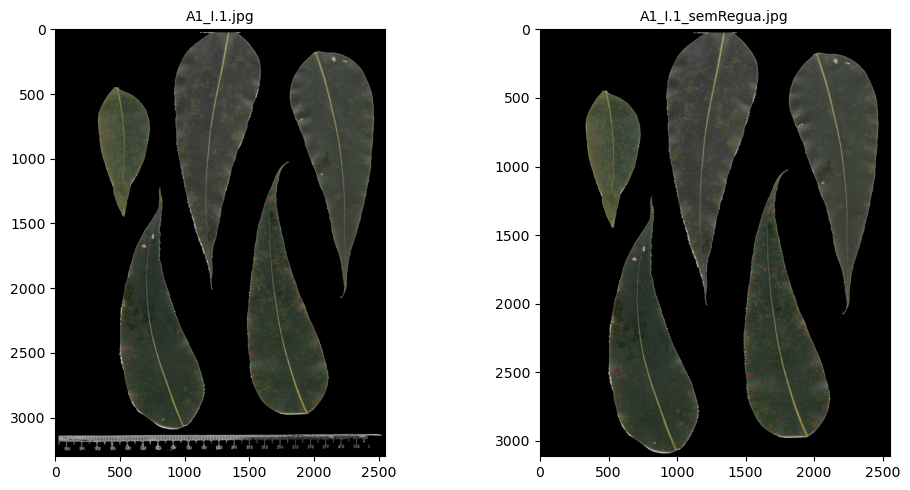

Fazenda_Exemplo_01: 2 imagens processadas


In [2]:
# BLOOCO PARA TESTE DE LIMIAR E VISUALIZAÇÃO DAS IMAGENS
# Visualização das imagens reais dentro das áreas detectadas das folhas
from matplotlib.pyplot import figure, subplot, imshow, title, tight_layout, show
from numpy import dstack

# Processamento e visualização
for fazenda in fazendas:
    
    fazendaPathImagens = listdir(path.join(strPath, fazenda))
    
    # Filtrar apenas arquivos de imagem
    imagens = [img for img in fazendaPathImagens if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not imagens:
        print(f'{fazenda}: Nenhuma imagem encontrada')
        continue
    
    # Criar figura para essa fazenda
    num_imagens = len(imagens)
    cols = 3
    rows = (num_imagens + cols - 1) // cols
    
    figure(figsize=(15, rows * 5))
    
    for idx, imagem in enumerate(imagens, 1):
        
        imgPath = path.join(strPath, fazenda, imagem)
        
        # Processar imagem
        img_original = imread(imgPath)
        imagem_cinza = cvtColor(img_original, COLOR_BGR2GRAY)
        imagem_cinza = 255 - imagem_cinza
        
        # Binarizar
        _, imagem_binaria = threshold(imagem_cinza, 50, 252, THRESH_BINARY)
        
        # Remover ruídos
        mascara = morphologyEx(imagem_binaria, MORPH_OPEN, getStructuringElement(MORPH_ELLIPSE, (5,5)))
        
        # Converter máscara para 3 canais (RGB)
        mascara_3d = dstack([mascara, mascara, mascara])
        
        # Aplicar máscara na imagem original (mostra apenas as folhas)
        img_folhas = (img_original * (mascara_3d > 0)).astype('uint8')
        
        # Plotar
        subplot(rows, cols, idx)
        imshow(cvtColor(img_folhas, COLOR_BGR2RGB))
        title(f'{imagem}', fontsize=10)
    
    tight_layout()
    show()
    
    print(f'{fazenda}: {num_imagens} imagens processadas')